In [3]:
!pip install pandas numpy matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 1.4 MB/s  0:00:07m0:00:0100:01


In [85]:
!pip install statsmodels

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.4/10.4 MB 1.4 MB/s  0:00:07m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [statsmodels] [statsmodels]


In [66]:
#Importing all the required libraries for analysis

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pylab as plt
%matplotlib inline
from matplotlib.pylab import rcParams
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

In [67]:
#Reading the dataset file and checking the size of file

In [15]:
data=pd.read_csv('HFCE_data.csv')
data.shape

(104, 2)

In [ ]:
#Creating the 'Date' as Index for data and viewing the dataset

In [16]:
data['Date'] = data['Date'].str.replace(' ', '-')
data.index = pd.PeriodIndex(data['Date'], freq='Q')
data = data.drop(columns=['Date'])
data.columns = ['Household Final Consumption Expenditure']
print(data.head())
print(data.tail())

        Household Final Consumption Expenditure
Date                                           
2000Q1                                  1317540
2000Q2                                  1348116
2000Q3                                  1339907
2000Q4                                  1349704
2001Q1                                  1373330
        Household Final Consumption Expenditure
Date                                           
2024Q4                                  4122637
2025Q1                                  4154067
2025Q2                                  4194860
2025Q3                                  4224486
2025Q4                                  4279509


In [68]:
#Visualizing the Time Series plot for the number of HFCE

<Axes: title={'center': 'Household Final Consumption Expenditure'}, xlabel='Date'>

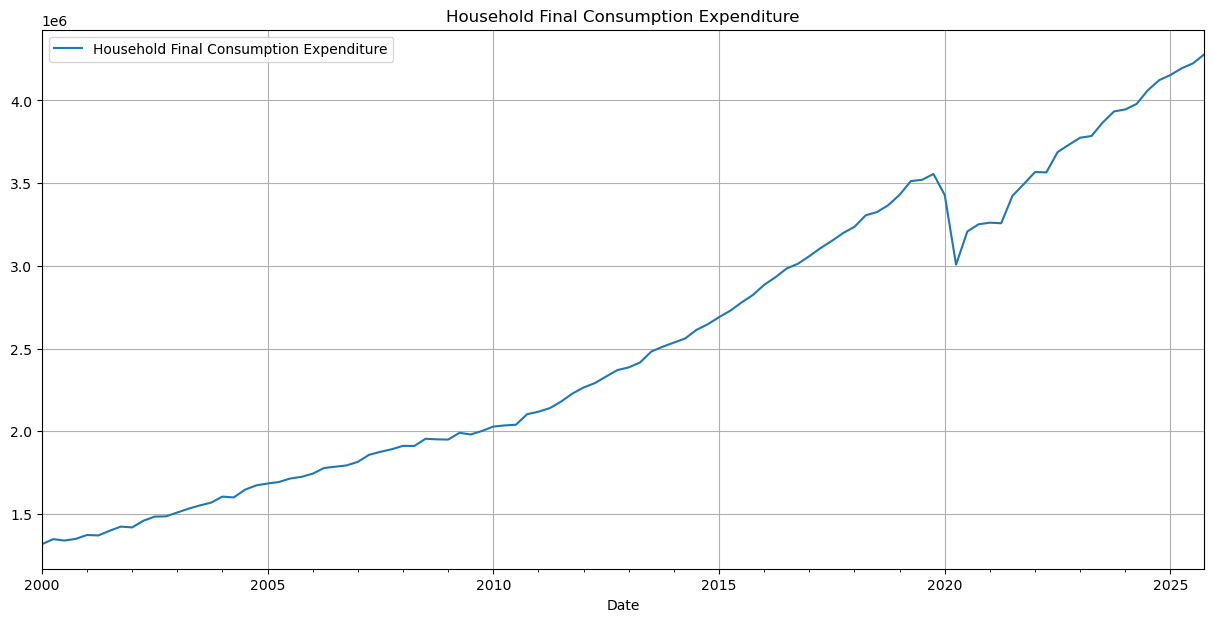

In [17]:
data.plot(figsize=(15, 7), title="Household Final Consumption Expenditure", grid=True)

In [70]:
#As we know that, A stationary Time Series is one which characteristics like mean and variance does not change over time
#Preparing the data for analyzing the Rolling Mean and Standard Deviation to check stationarity for given Time Series

In [18]:
rolmean=data.rolling(window=12).mean()
rolstd=data.rolling(window=12).std()
print(rolmean.head(15))
print(rolstd.head(15))

        Household Final Consumption Expenditure
Date                                           
2000Q1                                      NaN
2000Q2                                      NaN
2000Q3                                      NaN
2000Q4                                      NaN
2001Q1                                      NaN
2001Q2                                      NaN
2001Q3                                      NaN
2001Q4                                      NaN
2002Q1                                      NaN
2002Q2                                      NaN
2002Q3                                      NaN
2002Q4                             1.397618e+06
2003Q1                             1.413603e+06
2003Q2                             1.428958e+06
2003Q3                             1.446628e+06
        Household Final Consumption Expenditure
Date                                           
2000Q1                                      NaN
2000Q2                                  

In [71]:
#Plotting the Rolling Mean and Standard Deviation, which has window of 12
#By looking below plot, we conclude that, it is non-stationary bcoz mean and variance is not constant

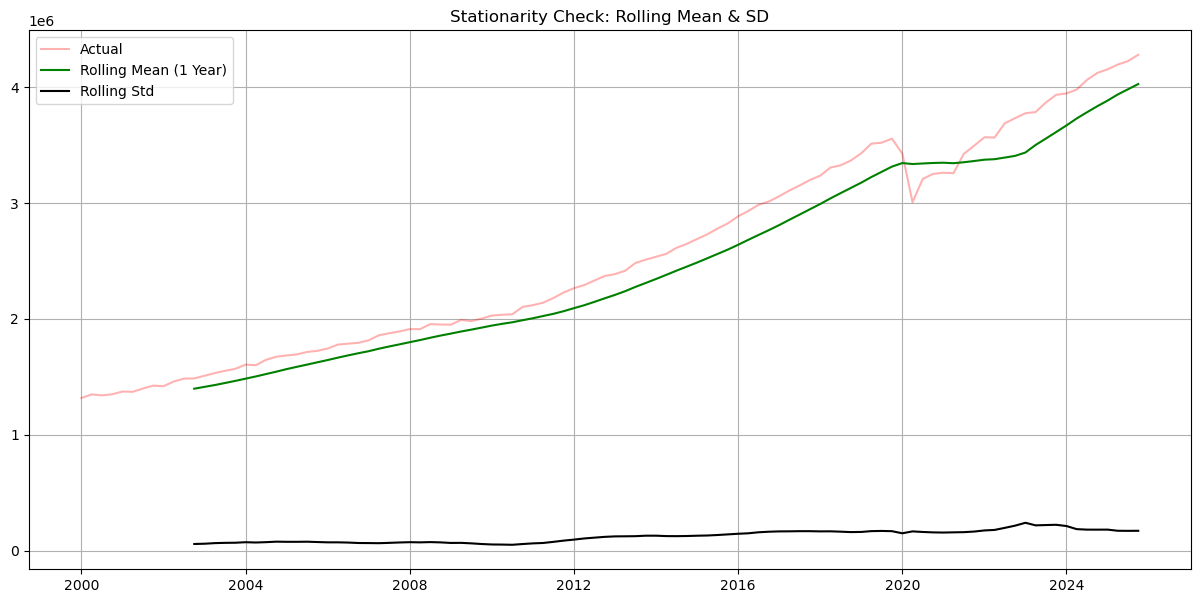

In [23]:
# 1. Rename the column to 'Expenditure' if you haven't yet
data.columns = ['Expenditure']

# 2. Setup the figure
plt.figure(figsize=(15,7))

# 3. Use .to_timestamp() so Matplotlib can read the Quarters
plt.plot(data.index.to_timestamp(), data['Expenditure'], color='red', label='Actual', alpha=0.3)
plt.plot(rolmean.index.to_timestamp(), rolmean, color='green', label='Rolling Mean (1 Year)')
plt.plot(rolstd.index.to_timestamp(), rolstd, color='black', label='Rolling Std')

# 4. Add the labels and legend
plt.legend(loc='best')
plt.title('Stationarity Check: Rolling Mean & SD')
plt.grid(True)
plt.savefig('m.png', dpi=300, bbox_inches='tight')
plt.show()

In [2]:
#Using ADF (Augmented Dickey-Fuller Test) to check stationarity, another approach based on statistics.
#ADF has : Null hypothesis - Time Series is non-stationary

In [86]:
from statsmodels.tsa.stattools import adfuller
print('Dickey-Fuller Test: ')
dftest=adfuller(data['Expenditure'], autolag='AIC')
dfoutput=pd.Series(dftest[0:4], index=['Test Statistic','p-value','Lags Used','No. of Obs'])
for key,value in dftest[4].items():
    dfoutput['Critical Value (%s)'%key] = value
print(dfoutput)

Dickey-Fuller Test: 
Test Statistic            1.202203
p-value                   0.996001
Lags Used                 0.000000
No. of Obs              103.000000
Critical Value (1%)      -3.495493
Critical Value (5%)      -2.890037
Critical Value (10%)     -2.581971
dtype: float64


In [1]:
#From above ADF test, we fail to reject the null hypothesis, since p-value is greater than 0.05
#Suitable for ARIMA

In [2]:
#The code for stationarity checking ends here